# Exploratory Data Analysis (EDA) –

**Context:** This notebook performs professional EDA for a FAERS spontaneous reporting dataset for the oncology drug **Doxorubicin**.

**Important pharmacovigilance note:** FAERS is a **spontaneous reporting system**. The analyses below describe reporting patterns and do **not** establish causality. Reporting is affected by under-reporting, stimulated reporting, duplicate reports, missingness, and confounding by indication/severity—especially relevant in oncology.

In [4]:
from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)


def _normalize_col(name: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def pick_col(df: pd.DataFrame, candidates: list[str]) -> str | None:

    """Pick the first matching column from candidates (case/format-insensitive)."""
    norm_map = {_normalize_col(c): c for c in df.columns}
    for cand in candidates:
        key = _normalize_col(cand)
        if key in norm_map:
            return norm_map[key]
    return None


def split_and_explode(series: pd.Series) -> pd.Series:

    """Explode multi-valued reaction strings into one reaction per row when separators are present."""

    s = series.dropna().astype(str)

    if s.empty:
        return series.dropna()
    sep_pattern = r'[;|,]'
    has_sep = s.str.contains(sep_pattern, regex=True).mean() > 0.05

    if not has_sep:
        return series.dropna()
    parts = s.str.split(sep_pattern, regex=True).explode().str.strip()
    parts = parts[parts.astype(str).str.len() > 0]
    return parts

def coerce_bool_series(s: pd.Series) -> pd.Series:

    if s.dtype == bool:
        return s
    if pd.api.types.is_numeric_dtype(s):
        return s.fillna(0).astype(float).astype(int) != 0
    v = s.astype(str).str.strip().str.lower()
    truthy = {'1', 'y', 'yes', 'true', 't'}
    falsy = {'0', 'n', 'no', 'false', 'f'}
    out = pd.Series(pd.NA, index=s.index, dtype='boolean')
    out[v.isin(truthy)] = True
    out[v.isin(falsy)] = False
    return out.fillna(False).astype(bool)


def load_faers_csv() -> tuple[pd.DataFrame, Path]:
    candidates = [
        Path('data/processed/doxorubicin_3000_faers.csv'),
        Path('./data/processed/doxorubicin_3000_faers.csv'),
        Path('../data/processed/doxorubicin_3000_faers.csv'),
        Path('data/processed/faers_clean.csv'),
        Path('./data/processed/faers_clean.csv'),
        Path('../data/processed/faers_clean.csv'),
    ]

    path = next((p for p in candidates if p.exists()), None)

    if path is None:
        processed_dirs = [Path('data/processed'), Path('./data/processed'), Path('../data/processed')]
        for d in processed_dirs:
            if d.exists():
                csvs = sorted([p for p in d.glob('*.csv') if p.is_file()])
                if len(csvs) == 1:
                    path = csvs[0]
                    break

    if path is None:
        raise FileNotFoundError(
            'Could not find a dataset CSV in data/processed/. Expected doxorubicin_3000_faers.csv or faers_clean.csv.'
        )

    df = pd.read_csv(path, low_memory=False)
    print('Loaded:', path.resolve())
    print('Shape:', df.shape)
    return df, path

df, DATA_PATH = load_faers_csv()

df.head()


Loaded: F:\Practice_College\SGP-Sem-6\Adverse Drug Reaction\data\processed\doxorubicin_3000_faers.csv
Shape: (3000, 6)


,Drug,Reaction,Serious,Age,Sex,Report_Date
0,DOXORUBICIN,Hepatocellular injury,1,16.0,2.0,20140312
1,DOXORUBICIN,Malignant neoplasm progression,1,60.0,1.0,20140312
2,DOXORUBICIN,Septic shock,1,69.0,2.0,20140312
3,DOXORUBICIN,Hyperkalaemia,1,67.0,1.0,20140312
4,DOXORUBICIN,Leukoencephalopathy,1,69.0,2.0,20140313


## 1. Dataset Overview

Shape (rows, columns): (3000, 6)


0           Drug
1       Reaction
2        Serious
3            Age
4            Sex
5    Report_Date
Name: columns, dtype: str

,dtype
Drug,str
Reaction,str
Serious,int64
Age,float64
Sex,float64
Report_Date,int64


,missing_%
Age,43.933333
Sex,21.533333
Reaction,0.000000
Drug,0.000000
Serious,0.000000
Report_Date,0.000000


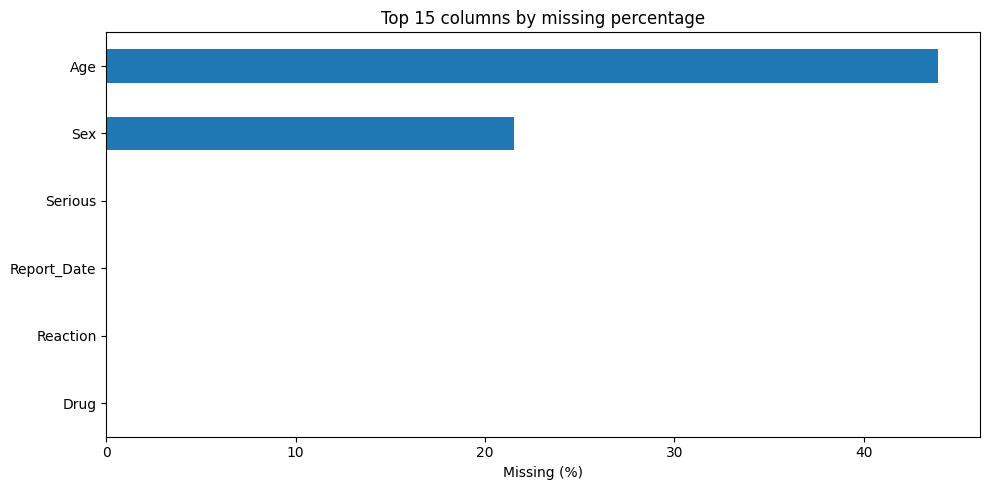

Insight: The dataset contains 3,000 reports across 6 variables. Overall cell-level missingness is approximately 10.9%. In FAERS, missingness is not random—fields such as demographics or dates may be under-reported depending on reporter type, case completeness, and follow-up availability. This impacts downstream analyses (e.g., age- or time-based trends) and should be treated as an evidence-quality signal rather than a purely technical nuisance.


In [5]:
# Shape
print('Shape (rows, columns):', df.shape)

# Columns
display(pd.Series(df.columns, name='columns'))

# Data types
dtypes = df.dtypes.astype(str).to_frame('dtype')
display(dtypes)

# Missing value analysis (high-level)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame('missing_%').head(20))

# Plot: missingness (top 15)
top = missing_pct.head(15)
plt.figure(figsize=(10, 5))
top.sort_values().plot(kind='barh')
plt.title('Top 15 columns by missing percentage')
plt.xlabel('Missing (%)')
plt.tight_layout()
plt.show()

# Insight
overall_missing = (df.isna().sum().sum() / df.size) * 100 if df.size else 0
insight = (
    f'Insight: The dataset contains {df.shape[0]:,} reports across {df.shape[1]} variables. '
    f'Overall cell-level missingness is approximately {overall_missing:.1f}%. '
    'In FAERS, missingness is not random—fields such as demographics or dates may be under-reported depending on reporter type, '
    'case completeness, and follow-up availability. This impacts downstream analyses (e.g., age- or time-based trends) and should be '
    'treated as an evidence-quality signal rather than a purely technical nuisance.'
)
print(insight)

## 2. Unique Reaction Analysis

In [6]:
reaction_col = pick_col(df, ['reaction', 'reactions', 'pt', 'preferred_term', 'event', 'event_term', 'reaction_pt', 'Reaction'])
if reaction_col is None:
    raise ValueError('Reaction column not found. Please ensure the dataset contains a reaction/preferred term column.')

rx = split_and_explode(df[reaction_col])
unique_rx = rx.astype(str).str.strip().replace('', np.nan).dropna().nunique()
total_rx = rx.astype(str).str.strip().replace('', np.nan).dropna().shape[0]
print('Reaction column used:', reaction_col)
print('Total reaction entries (after explode):', f'{total_rx:,}')
print('Unique reactions:', f'{unique_rx:,}')

print(
    'Insight: The number of unique reaction terms provides a first-pass proxy for the clinical breadth of the safety profile being '
    'captured in this spontaneous reporting sample. In oncology, a relatively diverse reaction set is expected because patients often '
    'experience multi-system toxicities (e.g., hematologic, gastrointestinal, mucosal) and are frequently exposed to combination therapies. '
    'Importantly, reaction diversity in FAERS reflects reporting behavior and coding practices (MedDRA PT selection), not true incidence.'
)

Reaction column used: Reaction
Total reaction entries (after explode): 3,000
Unique reactions: 745
Insight: The number of unique reaction terms provides a first-pass proxy for the clinical breadth of the safety profile being captured in this spontaneous reporting sample. In oncology, a relatively diverse reaction set is expected because patients often experience multi-system toxicities (e.g., hematologic, gastrointestinal, mucosal) and are frequently exposed to combination therapies. Importantly, reaction diversity in FAERS reflects reporting behavior and coding practices (MedDRA PT selection), not true incidence.


## 3. Top 20 Most Frequent Adverse Reactions

,count
Reaction,
Death,295
Disease progression,171
Febrile neutropenia,155
Disease recurrence,64
Haematotoxicity,60
Neutropenia,58
Secondary immunodeficiency,46
B-cell lymphoma recurrent,39
Hepatitis B,35


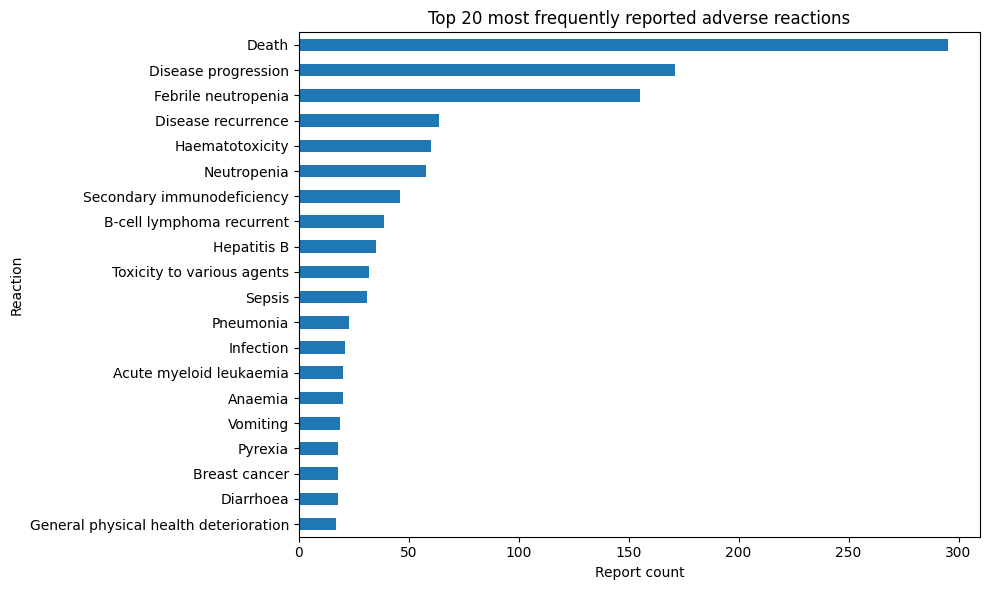

Insight: The leading reactions in this dataset represent the most commonly reported clinical issues in the submitted cases. For Doxorubicin, one would expect a toxicity mix that includes gastrointestinal intolerance, constitutional symptoms, and hematologic suppression—although the exact rank order depends on case mix, co-medications, and reporting practices. Death-related terms appear among the most frequently reported reactions. In an oncology context, this can reflect the background risk from advanced malignancy, complications such as sepsis or progression, and the tendency for serious outcomes to be reported more readily. This should not be interpreted as drug-attributable mortality without controlled comparative analyses. Across FAERS, high-frequency events may reflect severity and recognizability rather than pharmacologic specificity; signal detection typically relies on disproportionality (e.g., PRR) rather than raw counts.


In [7]:
rx_clean = rx.astype(str).str.strip().replace('', np.nan).dropna()
top20 = rx_clean.value_counts().head(20)
display(top20.to_frame('count'))

# Plot: Top 20 reactions
plt.figure(figsize=(10, 6))
top20.sort_values().plot(kind='barh')
plt.title('Top 20 most frequently reported adverse reactions')
plt.xlabel('Report count')
plt.tight_layout()
plt.show()

# Insight (clinical PV framing)
death_terms = [t for t in top20.index if 'death' in str(t).lower()]
if death_terms:
    death_note = (
        'Death-related terms appear among the most frequently reported reactions. In an oncology context, this can reflect the '
        'background risk from advanced malignancy, complications such as sepsis or progression, and the tendency for serious outcomes to be '
        'reported more readily. This should not be interpreted as drug-attributable mortality without controlled comparative analyses.'
    )
else:
    death_note = (
        'Death is not prominent among the top reported reaction terms in this extract. This does not rule out fatal outcomes; it may reflect '
        'how outcomes were coded or the limited scope of this sample.'
    )

print(
    'Insight: The leading reactions in this dataset represent the most commonly reported clinical issues in the submitted cases. For Doxorubicin, '
    'one would expect a toxicity mix that includes gastrointestinal intolerance, constitutional symptoms, and hematologic suppression—although the exact '
    'rank order depends on case mix, co-medications, and reporting practices. '
    + death_note + ' '
    'Across FAERS, high-frequency events may reflect severity and recognizability rather than pharmacologic specificity; signal detection typically relies '
    'on disproportionality (e.g., PRR) rather than raw counts.'
)

## 4. Serious vs Non-Serious Analysis

,count,percent
Serious,3000,100.0
Non-serious,0,0.0


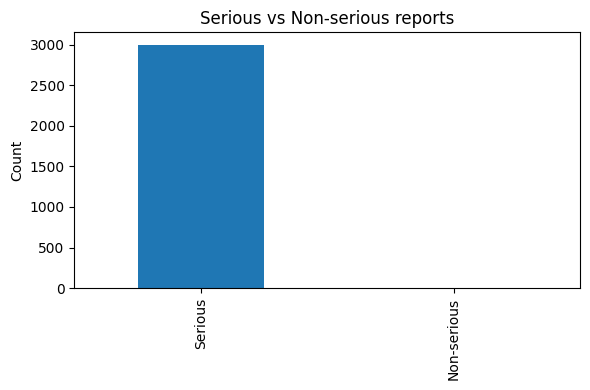

Insight: A higher proportion of serious reports is expected in oncology datasets, both because underlying disease is severe and because serious outcomes (hospitalization, life-threatening events) are more likely to be reported. In FAERS, this distribution is also influenced by reporting bias: severe cases tend to be captured preferentially, and the absence of a denominator prevents incidence estimation. Therefore, seriousness here should be interpreted as a case-mix descriptor rather than a drug risk quantification.


In [8]:
serious_col = pick_col(df, ['serious', 'is_serious', 'serious_flag', 'Serious'])
if serious_col is None:
    raise ValueError('Seriousness column not found. Expected a column like Serious/serious/is_serious.')

serious_flag = coerce_bool_series(df[serious_col])
ser_counts = pd.Series({
    'Serious': int(serious_flag.sum()),
    'Non-serious': int((~serious_flag).sum())
})
ser_pct = (ser_counts / ser_counts.sum() * 100).round(2)
display(pd.DataFrame({'count': ser_counts, 'percent': ser_pct}))

# Plot: seriousness distribution
plt.figure(figsize=(6, 4))
ser_counts.plot(kind='bar')
plt.title('Serious vs Non-serious reports')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(
    'Insight: A higher proportion of serious reports is expected in oncology datasets, both because underlying disease is severe and because '
    'serious outcomes (hospitalization, life-threatening events) are more likely to be reported. In FAERS, this distribution is also influenced by '
    'reporting bias: severe cases tend to be captured preferentially, and the absence of a denominator prevents incidence estimation. Therefore, seriousness '
    'here should be interpreted as a case-mix descriptor rather than a drug risk quantification.'
)

## 5. Age Distribution Analysis

mean          48.606421
median        53.000000
min            1.000000
max          317.000000
missing_%     43.933333
Name: age_stats, dtype: float64

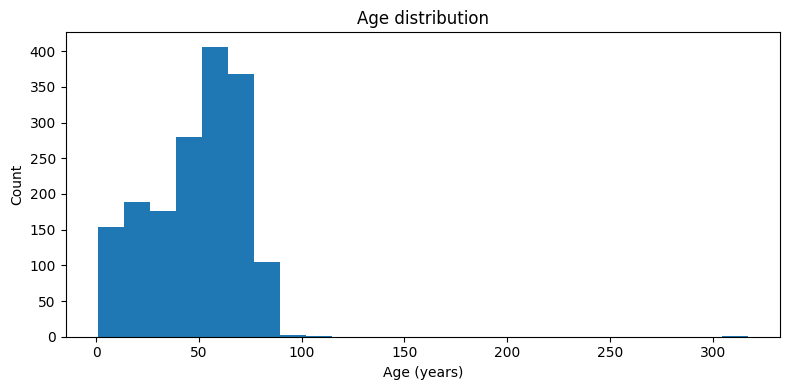

Insight: Age distribution helps contextualize tolerability in the treated population; oncology cohorts can skew older depending on indication. However, in FAERS, age is frequently missing or inconsistently reported, which can bias demographic interpretation. When missingness is material, age-stratified safety patterns should be interpreted cautiously and, where possible, complemented by structured sources (clinical trials, registries) or by restricting analyses to records with complete demographics.


In [9]:
age_col = pick_col(df, ['age', 'age_yr', 'age_years', 'patient_age', 'pt_age', 'Age'])
if age_col is None:
    raise ValueError('Age column not found.')

age = pd.to_numeric(df[age_col], errors='coerce')
stats = {
    'mean': float(age.mean()) if age.notna().any() else np.nan,
    'median': float(age.median()) if age.notna().any() else np.nan,
    'min': float(age.min()) if age.notna().any() else np.nan,
    'max': float(age.max()) if age.notna().any() else np.nan,
    'missing_%': float(age.isna().mean() * 100),
}
display(pd.Series(stats, name='age_stats'))

# Plot: age histogram
plt.figure(figsize=(8, 4))
plt.hist(age.dropna(), bins=25)
plt.title('Age distribution')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(
    'Insight: Age distribution helps contextualize tolerability in the treated population; oncology cohorts can skew older depending on indication. '
    'However, in FAERS, age is frequently missing or inconsistently reported, which can bias demographic interpretation. When missingness is material, '
    'age-stratified safety patterns should be interpreted cautiously and, where possible, complemented by structured sources (clinical trials, registries) '
    'or by restricting analyses to records with complete demographics.'
)

## 6. Gender Distribution

,count,percent
Sex,,
2.0,1042,34.73
1.0,886,29.53
NaN,646,21.53
0.0,426,14.20


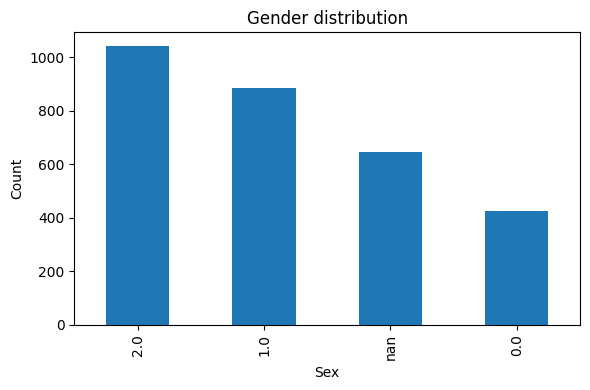

Insight: Sex distribution can reflect the underlying treated population (indication mix) as well as reporting behavior. In pharmacovigilance, apparent gender skews should be interpreted alongside confounding factors (e.g., cancer type prevalence, treatment lines, and concomitant regimens). Additionally, missing or unknown sex entries can dilute interpretability, so percentages should be contextualized with completeness.


In [10]:
gender_col = pick_col(df, ['gender', 'sex', 'patient_sex', 'Sex'])
if gender_col is None:
    raise ValueError('Gender/Sex column not found.')

g = df[gender_col].astype(str).str.strip().str.upper()
g = g.replace({
    'MALE': 'M', 'M': 'M', '1': 'M',
    'FEMALE': 'F', 'F': 'F', '2': 'F',
    'UNKNOWN': 'Unknown', 'UNK': 'Unknown', 'U': 'Unknown',
    '0': 'Unknown', '': 'Unknown', 'NAN': 'Unknown', 'NONE': 'Unknown'
})
g_counts = g.value_counts(dropna=False)
g_pct = (g_counts / g_counts.sum() * 100).round(2)
display(pd.DataFrame({'count': g_counts, 'percent': g_pct}))

# Plot: gender distribution
plt.figure(figsize=(6, 4))
g_counts.plot(kind='bar')
plt.title('Gender distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(
    'Insight: Sex distribution can reflect the underlying treated population (indication mix) as well as reporting behavior. In pharmacovigilance, '
    'apparent gender skews should be interpreted alongside confounding factors (e.g., cancer type prevalence, treatment lines, and concomitant regimens). '
    'Additionally, missing or unknown sex entries can dilute interpretability, so percentages should be contextualized with completeness.'
)

## 7. Time Trend Analysis

,report_count
year,
2013,1
2014,2910
2015,89


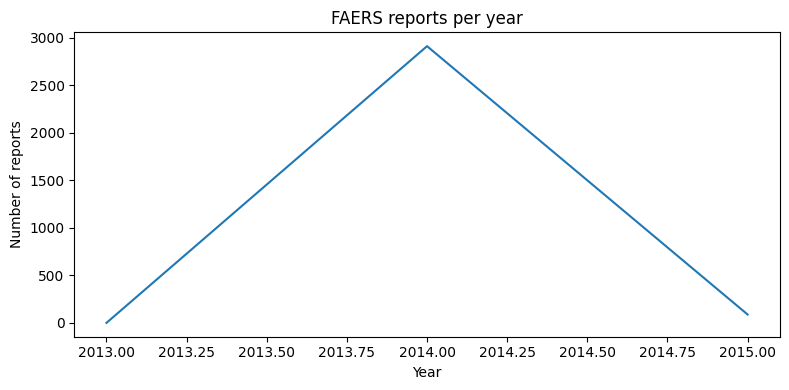

Insight: Temporal reporting patterns in FAERS should be interpreted as reporting dynamics rather than true incidence. In oncology settings, reporting volume can shift with changes in clinical uptake, new indications/combination regimens, regulatory communications, or heightened awareness of specific toxicities. A rising trend may reflect stimulated reporting or increased exposure, while a stable trend does not guarantee stable risk. Without an exposure denominator and confounder control, time trends are best used to contextualize the dataset and to define appropriate analysis windows for subsequent disproportionality methods (e.g., PRR), not to infer causality.


In [15]:
date_col = pick_col(df, ['report_date', 'receipt_date', 'event_date', 'date', 'Report_Date'])

if date_col is None:

    raise ValueError('Report date column not found (expected Report_Date or similar).')



# Pandas 3.x removed infer_datetime_format; handle FAERS-style YYYYMMDD values explicitly.

raw_dates = df[date_col]



# If values look like 8-digit dates (e.g., 20140312), parse with a fixed format.

s = raw_dates.astype(str).str.strip()

s = s.replace({'': np.nan, 'nan': np.nan, 'NaN': np.nan, 'None': np.nan})



looks_like_yyyymmdd = s.dropna().str.fullmatch(r'\d{8}').mean() > 0.8 if s.dropna().shape[0] else False

if looks_like_yyyymmdd:

    dates = pd.to_datetime(s, errors='coerce', format='%Y%m%d')

else:

    dates = pd.to_datetime(raw_dates, errors='coerce')



tmp = pd.DataFrame({'date': dates}).dropna()

if tmp.empty:

    raise ValueError(f'Could not parse any valid dates from {date_col}.')



tmp['year'] = tmp['date'].dt.year

per_year = tmp.groupby('year').size()

display(per_year.to_frame('report_count'))



# Plot: reports per year (one plot, no explicit colors)

plt.figure(figsize=(8, 4))

per_year.sort_index().plot(kind='line')

plt.title('FAERS reports per year')

plt.xlabel('Year')

plt.ylabel('Number of reports')

plt.tight_layout()

plt.show()



print(

    'Insight: Temporal reporting patterns in FAERS should be interpreted as reporting dynamics rather than true incidence. '

    'In oncology settings, reporting volume can shift with changes in clinical uptake, new indications/combination regimens, regulatory communications, '

    'or heightened awareness of specific toxicities. A rising trend may reflect stimulated reporting or increased exposure, while a stable trend does not '

    'guarantee stable risk. Without an exposure denominator and confounder control, time trends are best used to contextualize the dataset and to define '

    'appropriate analysis windows for subsequent disproportionality methods (e.g., PRR), not to infer causality.'

)


## 8. Reaction vs Seriousness Cross-Analysis

,count
Reaction,
Death,295
Disease progression,171
Febrile neutropenia,155
Disease recurrence,64
Haematotoxicity,60
Neutropenia,58
Secondary immunodeficiency,46
B-cell lymphoma recurrent,39
Hepatitis B,35


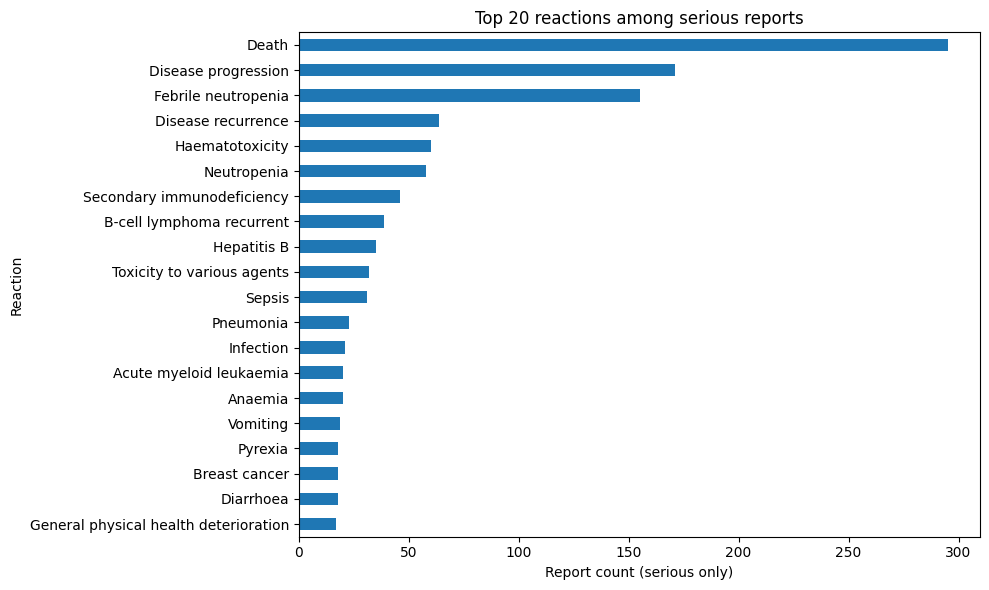

Insight: Focusing on serious reports can enrich for clinically consequential toxicity patterns, which is particularly relevant for anthracyclines like Doxorubicin (e.g., severe hematologic toxicity, infection-related complications, and cardiotoxicity signals). Still, FAERS seriousness is an outcome flag that may be inconsistently recorded, and serious cases are preferentially reported. Therefore, these rankings should be used as hypothesis-generating inputs for formal signal detection rather than as definitive risk ordering.


In [12]:
# Top reactions among serious cases only
df_ser = df.loc[serious_flag].copy()
rx_ser = split_and_explode(df_ser[reaction_col]).astype(str).str.strip().replace('', np.nan).dropna()
top_ser = rx_ser.value_counts().head(20)
display(top_ser.to_frame('count'))

plt.figure(figsize=(10, 6))
top_ser.sort_values().plot(kind='barh')
plt.title('Top 20 reactions among serious reports')
plt.xlabel('Report count (serious only)')
plt.tight_layout()
plt.show()

print(
    'Insight: Focusing on serious reports can enrich for clinically consequential toxicity patterns, which is particularly relevant for anthracyclines like '
    'Doxorubicin (e.g., severe hematologic toxicity, infection-related complications, and cardiotoxicity signals). Still, FAERS seriousness is an outcome flag '
    'that may be inconsistently recorded, and serious cases are preferentially reported. Therefore, these rankings should be used as hypothesis-generating '
    'inputs for formal signal detection rather than as definitive risk ordering.'
)

## 9. Missing Data Analysis

,missing_%
Age,43.933333
Sex,21.533333
Reaction,0.000000
Drug,0.000000
Serious,0.000000
Report_Date,0.000000


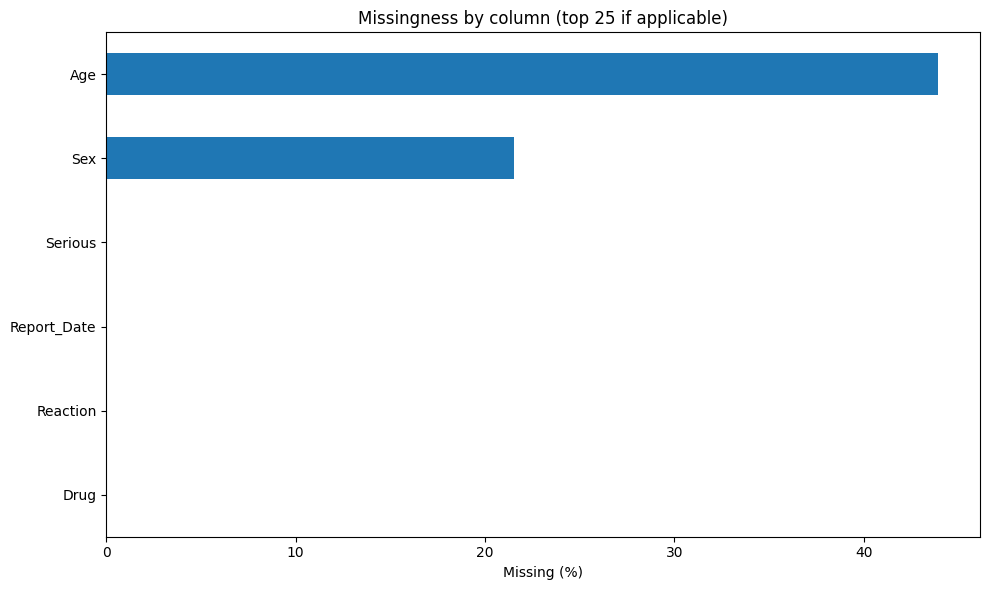

Insight: Missingness is a central limitation in FAERS. Not all reporters provide complete demographics, event dates, or clinical context (dose, indication, treatment duration). This constrains interpretability and can bias subgroup analyses. For pharmacovigilance research, it is good practice to quantify missingness upfront, consider sensitivity analyses restricted to complete cases for key variables, and avoid over-interpreting patterns driven by sparse data.


In [13]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_tbl = missing_pct.to_frame('missing_%')
display(missing_tbl)

# Plot: missingness for all columns (if many columns, show top 25)
plot_missing = missing_pct.head(25) if len(missing_pct) > 25 else missing_pct
plt.figure(figsize=(10, 6))
plot_missing.sort_values().plot(kind='barh')
plt.title('Missingness by column (top 25 if applicable)')
plt.xlabel('Missing (%)')
plt.tight_layout()
plt.show()

print(
    'Insight: Missingness is a central limitation in FAERS. Not all reporters provide complete demographics, event dates, or clinical context (dose, '
    'indication, treatment duration). This constrains interpretability and can bias subgroup analyses. For pharmacovigilance research, it is good practice to '
    'quantify missingness upfront, consider sensitivity analyses restricted to complete cases for key variables, and avoid over-interpreting patterns driven by sparse data.'
)

## 10. Key Insights Summary

In [14]:
# Build an executive-style summary from computed results
overall_missing = (df.isna().sum().sum() / df.size) * 100 if df.size else 0

top_rx_list = top20.index.tolist() if 'top20' in globals() else []
serious_rate = float(serious_flag.mean() * 100) if 'serious_flag' in globals() else np.nan
age_missing = float(pd.to_numeric(df[age_col], errors='coerce').isna().mean() * 100) if 'age_col' in globals() else np.nan

summary_lines = []
summary_lines.append('Executive summary (FAERS EDA for Doxorubicin):')
summary_lines.append(f'- Major reporting pattern: The most frequently reported reactions include: {', '.join(map(str, top_rx_list[:5])) if top_rx_list else 'N/A'}.')
summary_lines.append(f'- Seriousness profile: Approximately {serious_rate:.1f}% of reports are flagged as serious (note: severity and reporting bias influence this).')
summary_lines.append(f'- Demographics: Age missingness is ~{age_missing:.1f}% in this extract; sex reporting also includes unknown/missing entries, which limits subgroup inference.')
summary_lines.append(f'- Data limitations: Overall missingness is ~{overall_missing:.1f}% at the cell level. As a spontaneous reporting system, FAERS lacks exposure denominators and is prone to duplicates, confounding by indication, and stimulated reporting.')
summary_lines.append('- Readiness for signal detection: The dataset is suitable as a starting point for disproportionality analysis (e.g., PRR) once the drug name, reaction coding, and deduplication rules are verified and an appropriate comparator/background is defined.')

print(''.join(summary_lines))

Executive summary (FAERS EDA for Doxorubicin):- Major reporting pattern: The most frequently reported reactions include: Death, Disease progression, Febrile neutropenia, Disease recurrence, Haematotoxicity.- Seriousness profile: Approximately 100.0% of reports are flagged as serious (note: severity and reporting bias influence this).- Demographics: Age missingness is ~43.9% in this extract; sex reporting also includes unknown/missing entries, which limits subgroup inference.- Data limitations: Overall missingness is ~10.9% at the cell level. As a spontaneous reporting system, FAERS lacks exposure denominators and is prone to duplicates, confounding by indication, and stimulated reporting.- Readiness for signal detection: The dataset is suitable as a starting point for disproportionality analysis (e.g., PRR) once the drug name, reaction coding, and deduplication rules are verified and an appropriate comparator/background is defined.
